X shape: (442, 10)
y shape: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000



Missing values per column:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


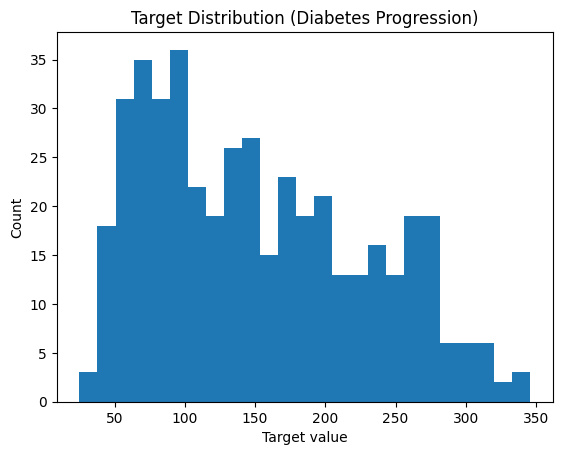

In [1]:
# Step 1: Data Preparation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes

# 1) Load the Diabetes dataset from sklearn
diabetes = load_diabetes()

# 2) Extract features (X), target (y), and feature names
X = diabetes.data                  # shape: (442, 10)
y = diabetes.target                # shape: (442,)
feature_names = diabetes.feature_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature names:", feature_names)

# 3) Convert to a DataFrame for easier exploration
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

# 4) Quick preview
display(df.head())

# 5) Summary statistics
display(df.describe())

# 6) Check missing values (usually none in this dataset)
print("\nMissing values per column:")
print(df.isna().sum())

# 7) Plot distribution of the target
plt.figure()
plt.hist(df["target"], bins=25)
plt.title("Target Distribution (Diabetes Progression)")
plt.xlabel("Target value")
plt.ylabel("Count")
plt.show()

In [2]:

# Helper Functions (Reusable)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred):
    """
    Computes standard regression metrics and returns them in a dictionary.
    """
    mae = mean_absolute_error(y_true, y_pred)           # average absolute error
    mse = mean_squared_error(y_true, y_pred)            # average squared error
    rmse = np.sqrt(mse)                                 # square root of MSE
    r2 = r2_score(y_true, y_pred)                        # goodness-of-fit score
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

def plot_pred_vs_actual(y_true, y_pred, title):
    """
    Scatter plot of predicted vs actual values.
    Perfect predictions lie on the diagonal line.
    """
    plt.figure()
    plt.scatter(y_true, y_pred, alpha=0.7)

    # Diagonal reference line (perfect prediction)
    min_v = min(y_true.min(), y_pred.min())
    max_v = max(y_true.max(), y_pred.max())
    plt.plot([min_v, max_v], [min_v, max_v])

    plt.title(title)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

Simple Linear Regression Metrics: {'MAE': 52.259976445345536, 'MSE': 4061.8259284949268, 'RMSE': np.float64(63.73245584860925), 'R2': 0.23335039815872138}


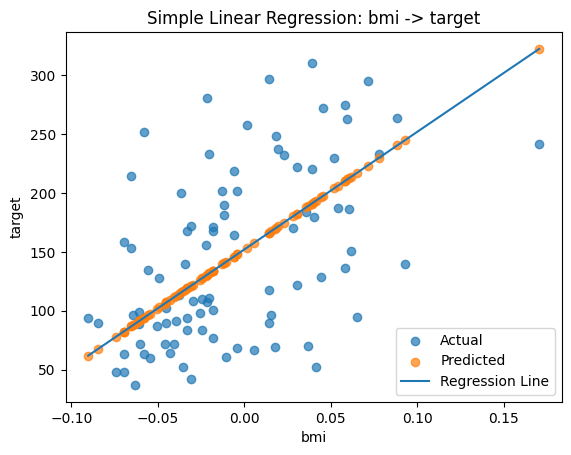

In [3]:

# Step 2: Simple Linear Regression
# Using ONE feature (example: BMI)


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1) Choose a single feature (bmi is commonly used)
single_feature = "bmi"
X_single = df[[single_feature]].values   # keep as 2D array (n, 1)

# 2) Split data into train and test sets
# test_size=0.2 means 20% test, 80% train
X_train, X_test, y_train, y_test = train_test_split(
    X_single, y, test_size=0.2, random_state=42
)

# 3) Create and train the linear regression model
lr_simple = LinearRegression()
lr_simple.fit(X_train, y_train)

# 4) Predict on the test set
y_pred = lr_simple.predict(X_test)

# 5) Evaluate using metrics
metrics_simple = regression_metrics(y_test, y_pred)
print("Simple Linear Regression Metrics:", metrics_simple)

# 6) Visualize: actual points vs predicted line
plt.figure()
plt.scatter(X_test, y_test, alpha=0.7, label="Actual")
plt.scatter(X_test, y_pred, alpha=0.7, label="Predicted")

# Create a smooth line for the regression curve
x_line = np.linspace(X_test.min(), X_test.max(), 200).reshape(-1, 1)
y_line = lr_simple.predict(x_line)
plt.plot(x_line, y_line, label="Regression Line")

plt.title("Simple Linear Regression: bmi -> target")
plt.xlabel("bmi")
plt.ylabel("target")
plt.legend()
plt.show()

Multiple Linear Regression Metrics: {'MAE': 42.79409467959994, 'MSE': 2900.193628493482, 'RMSE': np.float64(53.85344583676593), 'R2': 0.4526027629719195}


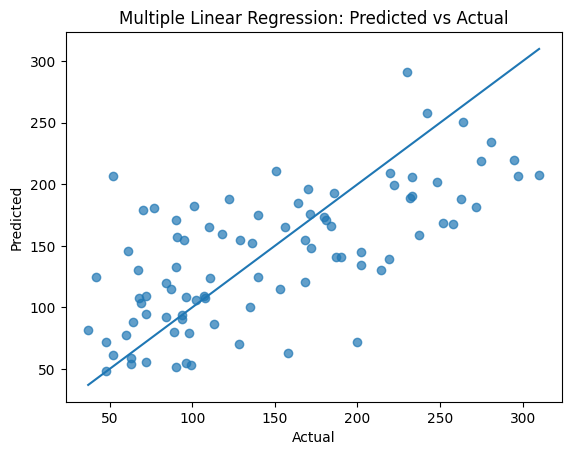

In [4]:

# Step 3: Multiple Linear Regression
# Using ALL features


# 1) Use all feature columns (10 features)
X_all = df[feature_names].values

# 2) Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# 3) Train multiple linear regression model
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

# 4) Predict on test set
y_pred = lr_multi.predict(X_test)

# 5) Evaluate
metrics_multi = regression_metrics(y_test, y_pred)
print("Multiple Linear Regression Metrics:", metrics_multi)

# 6) Plot predicted vs actual
plot_pred_vs_actual(y_test, y_pred, "Multiple Linear Regression: Predicted vs Actual")

,MAE,MSE,RMSE,R2
degree,,,,
1,52.259976,4061.825928,63.732456,0.233350
2,52.383912,4085.025481,63.914204,0.228972
3,52.181400,4064.443384,63.752987,0.232856
5,51.884611,4085.845567,63.920619,0.228817
7,52.407508,4193.098264,64.754137,0.208573
9,57.467425,7205.328683,84.884208,-0.359970


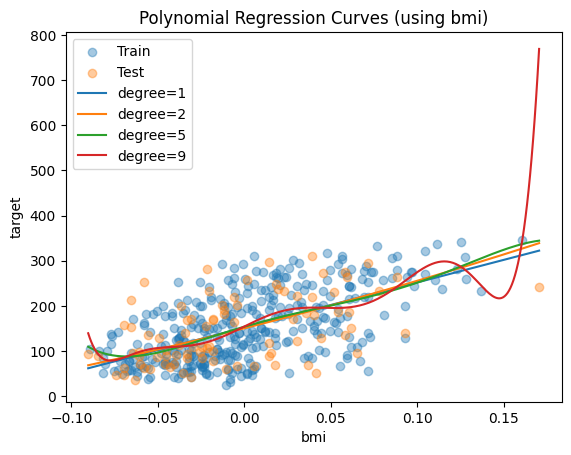

In [5]:

# Step 4: Polynomial Regression
# Use ONE feature (bmi) so we can visualize the curve


from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# 1) Prepare single-feature dataset again
X_single = df[[single_feature]].values

# 2) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_single, y, test_size=0.2, random_state=42
)

# 3) Try different polynomial degrees
degrees = [1, 2, 3, 5, 7, 9]
poly_results = []

for d in degrees:
    # Pipeline: polynomial features -> linear regression
    poly_model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("lr", LinearRegression())
    ])

    # Train model
    poly_model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = poly_model.predict(X_test)
    m = regression_metrics(y_test, y_pred)
    m["degree"] = d
    poly_results.append(m)

# 4) Show results table
poly_df = pd.DataFrame(poly_results).set_index("degree")
display(poly_df)

# 5) Visualize curves for a few degrees (show under/overfitting)
plt.figure()
plt.scatter(X_train, y_train, alpha=0.4, label="Train")
plt.scatter(X_test, y_test, alpha=0.4, label="Test")

x_grid = np.linspace(X_single.min(), X_single.max(), 300).reshape(-1, 1)

for d in [1, 2, 5, 9]:
    poly_model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("lr", LinearRegression())
    ])
    poly_model.fit(X_train, y_train)
    y_grid = poly_model.predict(x_grid)
    plt.plot(x_grid, y_grid, label=f"degree={d}")

plt.title("Polynomial Regression Curves (using bmi)")
plt.xlabel("bmi")
plt.ylabel("target")
plt.legend()
plt.show()

,MAE,MSE,RMSE,R2
alpha,,,,
0.01,42.794171,2900.075130,53.852346,0.452625
0.10,42.796235,2899.054556,53.842869,0.452818
1.00,42.811999,2892.014566,53.777454,0.454147
10.00,42.856825,2875.778718,53.626288,0.457211
100.00,43.250653,2858.224287,53.462363,0.460524


,MAE,MSE,RMSE,R2
alpha,,,,
0.01,42.795018,2898.368019,53.836493,0.452947
0.10,42.805234,2884.624289,53.708698,0.455541
1.00,42.802984,2824.568094,53.146666,0.466877
10.00,44.764599,2933.834730,54.164885,0.446253
100.00,64.006461,5361.533457,73.222493,-0.011963


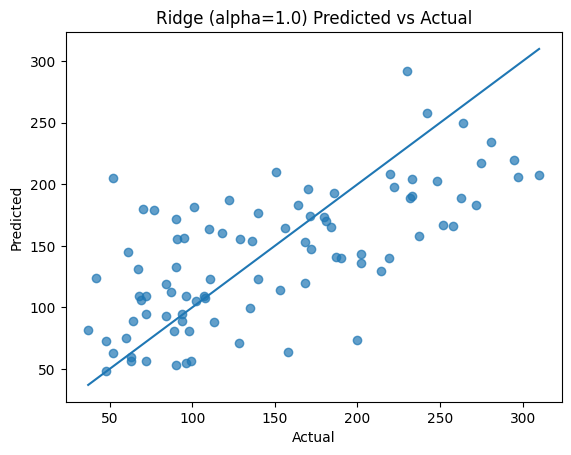

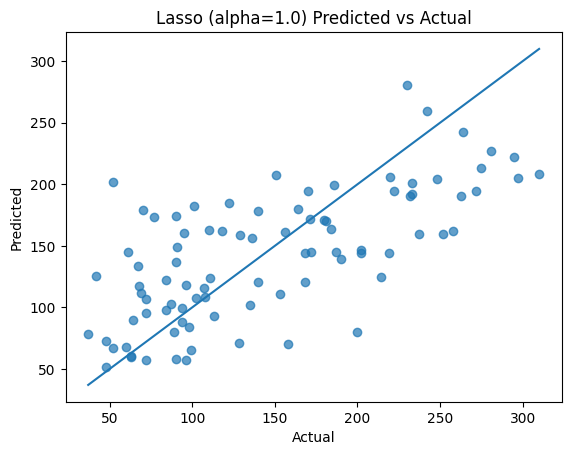

Lasso alpha = 1.0
Zero coefficients: 1 out of 10


,0
sex,-9.297519
s3,-9.024087
s1,-8.228172
s2,-0.000000
age,0.687032
s6,2.098647
s4,3.420861
bp,15.657314
s5,22.636465
bmi,26.219225


In [6]:

# Step 5: Regularization (Ridge + Lasso)
# Use ALL features, and Standardize them (important!)


from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

# 1) Use all features
X_all = df[feature_names].values

# 2) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# 3) Try multiple alpha values
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

# Ridge
ridge_results = []
for a in alphas:
    ridge_model = Pipeline([
        ("scaler", StandardScaler()),     # scale features
        ("ridge", Ridge(alpha=a))         # ridge regression
    ])
    ridge_model.fit(X_train, y_train)
    y_pred = ridge_model.predict(X_test)
    m = regression_metrics(y_test, y_pred)
    m["alpha"] = a
    ridge_results.append(m)

ridge_df = pd.DataFrame(ridge_results).set_index("alpha")
display(ridge_df)

# Lasso
lasso_results = []
for a in alphas:
    lasso_model = Pipeline([
        ("scaler", StandardScaler()),                 # scale features
        ("lasso", Lasso(alpha=a, max_iter=20000))     # lasso regression
    ])
    lasso_model.fit(X_train, y_train)
    y_pred = lasso_model.predict(X_test)
    m = regression_metrics(y_test, y_pred)
    m["alpha"] = a
    lasso_results.append(m)

lasso_df = pd.DataFrame(lasso_results).set_index("alpha")
display(lasso_df)

# 4) Visualize predicted vs actual for one chosen alpha (example alpha=1.0)
chosen_alpha = 1.0

ridge_best = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=chosen_alpha))
])
ridge_best.fit(X_train, y_train)
ridge_pred = ridge_best.predict(X_test)
plot_pred_vs_actual(y_test, ridge_pred, f"Ridge (alpha={chosen_alpha}) Predicted vs Actual")

lasso_best = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=chosen_alpha, max_iter=20000))
])
lasso_best.fit(X_train, y_train)
lasso_pred = lasso_best.predict(X_test)
plot_pred_vs_actual(y_test, lasso_pred, f"Lasso (alpha={chosen_alpha}) Predicted vs Actual")

# 5) Show how Lasso can set some coefficients to zero (feature selection)
lasso_coef = lasso_best.named_steps["lasso"].coef_
zero_count = np.sum(lasso_coef == 0)

print("Lasso alpha =", chosen_alpha)
print("Zero coefficients:", zero_count, "out of", len(lasso_coef))

coef_series = pd.Series(lasso_coef, index=feature_names).sort_values()
display(coef_series)

In [7]:
# ==============================
# Step 6: Model Comparison
# Summarize best/representative results in one table
# ==============================

summary_rows = []

# Simple LR metrics (from Step 2)
summary_rows.append({"Model": "Simple Linear (bmi)", **metrics_simple})

# Multiple LR metrics (from Step 3)
summary_rows.append({"Model": "Multiple Linear", **metrics_multi})

# Polynomial: choose best degree by highest R2
best_degree = poly_df["R2"].idxmax()
best_poly_metrics = poly_df.loc[best_degree].to_dict()
summary_rows.append({"Model": f"Polynomial (bmi) degree={best_degree}", **best_poly_metrics})

# Ridge: choose best alpha by highest R2
best_ridge_alpha = ridge_df["R2"].idxmax()
best_ridge_metrics = ridge_df.loc[best_ridge_alpha].to_dict()
summary_rows.append({"Model": f"Ridge alpha={best_ridge_alpha}", **best_ridge_metrics})

# Lasso: choose best alpha by highest R2
best_lasso_alpha = lasso_df["R2"].idxmax()
best_lasso_metrics = lasso_df.loc[best_lasso_alpha].to_dict()
summary_rows.append({"Model": f"Lasso alpha={best_lasso_alpha}", **best_lasso_metrics})

comparison_df = pd.DataFrame(summary_rows)
display(comparison_df)

,Model,MAE,MSE,RMSE,R2
0,Simple Linear (bmi),52.259976,4061.825928,63.732456,0.233350
1,Multiple Linear,42.794095,2900.193628,53.853446,0.452603
2,Polynomial (bmi) degree=1,52.259976,4061.825928,63.732456,0.233350
3,Ridge alpha=100.0,43.250653,2858.224287,53.462363,0.460524
4,Lasso alpha=1.0,42.802984,2824.568094,53.146666,0.466877


**Model comparison**

**Simple Linear (bmi):** MAE ≈ 52.26, RMSE ≈ 63.73, R² ≈ 0.233

Using only BMI explains only a small part of the target, so the errors are high.

**Polynomial (bmi) degree = 1:** Same as Simple Linear
Degree 1 is still just a straight line, so it does not change anything.

**Multiple Linear Regression:** MAE ≈ 42.79, RMSE ≈ 53.85, R² ≈ 0.453

Big improvement over single-feature because it uses all 10 features, so it captures more info about disease progression.

**Ridge (alpha = 100):** MAE ≈ 43.25, RMSE ≈ 53.46, R² ≈ 0.461

Slight improvement vs Multiple Linear. Ridge shrinks coefficients, which can reduce overfitting and make the model a bit more stable.

**Lasso (alpha = 1.0):** MAE ≈ 42.80, RMSE ≈ 53.15, R² ≈ 0.467

Best overall in your results (highest R² and lowest RMSE). Lasso can push weaker feature weights toward zero, so it may reduce noise and keep only useful signals.

**Insights gained**

A simple linear model with only one BMI feature performed worst by R² ≈ 0.23, indicating that a single feature is not enough to predict diabetes progression. The multiple linear regression model has improved significantly (R² ≈ 0.45), considering the fact that it makes use of all the features and takes into consideration more data relationships. The regularization models demonstrated some progress, so Ridge(alpha=100) advanced the model over the multiple linear regression, whereas the Lasso(alpha=1) offered the best results for the model, R²=≈0.47, with the lowest RMSE. This is indicative that the dataset has a lot to win from the use of multiple features, and, that, the inclusion of regularization, aids algorithm in controlling the magnitude of the coefficients. In this case, the best model is Lasso, although the variability of the dataset goes beyond the explanatory power of any simple linear model.